# Dataset Inspection

This notebook inspects the CBIS-DDSM dataset metadata and checks the label distribution.  
This step helps verify that the dataset was downloaded correctly and understand how the labels are organized before preparing the data for model training.

## Mount Google Drive

In [1]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

print("Google Drive mounted")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted


## Set project paths

In [2]:
import os

# Set project paths
PROJECT_ROOT = "/content/drive/MyDrive/breast_cancer_detection"
RAW_DATA_PATH = os.path.join(PROJECT_ROOT, "raw_data")
DATASET_PATH = os.path.join(PROJECT_ROOT, "dataset")

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"RAW_DATA_PATH: {RAW_DATA_PATH}")
print(f"DATASET_PATH: {DATASET_PATH}")

PROJECT_ROOT: /content/drive/MyDrive/breast_cancer_detection
RAW_DATA_PATH: /content/drive/MyDrive/breast_cancer_detection/raw_data
DATASET_PATH: /content/drive/MyDrive/breast_cancer_detection/dataset


## Dataset structure
Check that the project paths and raw dataset files are available.

In [3]:
# Check folder paths
print("Checking dataset structure")

print(f"Project root: {PROJECT_ROOT}")
print("Exists:" , os.path.exists(PROJECT_ROOT))

print(f"Raw data path: {RAW_DATA_PATH}")
print("Exists:", os.path.exists(RAW_DATA_PATH))

if os.path.exists(RAW_DATA_PATH):
    items = sorted(os.listdir(RAW_DATA_PATH))
    print(f"Items in raw_data: {len(items)}")
    for item in items[:20]:
        item_path = os.path.join(RAW_DATA_PATH, item)
        suffix = "/" if os.path.isdir(item_path) else ""
        print(f"- {item}{suffix}")
    if len(items) > 20:
        print(f"... and {len(items) - 20} more")

Checking dataset structure
Project root: /content/drive/MyDrive/breast_cancer_detection
Exists: True
Raw data path: /content/drive/MyDrive/breast_cancer_detection/raw_data
Exists: True
Items in raw_data: 3
- cbis-ddsm-breast-cancer-image-dataset.zip
- csv/
- jpeg/


## Load metadata
Load the metadata CSV file to inspect how images and labels are organized.

In [4]:
import glob
import pandas as pd
from IPython.display import display

# Load metadata
csv_paths = sorted(glob.glob(os.path.join(RAW_DATA_PATH, "**", "*.csv"), recursive=True))
print(f"Metadata CSV files found: {len(csv_paths)}")

metadata_tables = {}
for csv_path in csv_paths:
    try:
        df = pd.read_csv(csv_path)
        metadata_tables[csv_path] = df
    except Exception as e:
        print(f"Skipped {os.path.basename(csv_path)}: {e}")

if metadata_tables:
    metadata_path = next(iter(metadata_tables.keys()))
    metadata_df = metadata_tables[metadata_path].copy()
    print(f"Using metadata file: {metadata_path}")
    print(f"Shape: {metadata_df.shape}")
    # Check columns
    print("Columns:")
    print(metadata_df.columns.tolist())
    # Display first rows
    display(metadata_df.head())
else:
    metadata_df = None
    print("No readable metadata CSV found")

Metadata CSV files found: 6
Using metadata file: /content/drive/MyDrive/breast_cancer_detection/raw_data/csv/calc_case_description_test_set.csv
Shape: (326, 14)
Columns:
['patient_id', 'breast density', 'left or right breast', 'image view', 'abnormality id', 'abnormality type', 'calc type', 'calc distribution', 'assessment', 'pathology', 'subtlety', 'image file path', 'cropped image file path', 'ROI mask file path']


,patient_id,breast density,left or right breast,image view,abnormality id,abnormality type,calc type,calc distribution,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00038,2,LEFT,CC,1,calcification,PUNCTATE-PLEOMORPHIC,CLUSTERED,4,BENIGN,2,Calc-Test_P_00038_LEFT_CC/1.3.6.1.4.1.9590.100...,Calc-Test_P_00038_LEFT_CC_1/1.3.6.1.4.1.9590.1...,Calc-Test_P_00038_LEFT_CC_1/1.3.6.1.4.1.9590.1...
1,P_00038,2,LEFT,MLO,1,calcification,PUNCTATE-PLEOMORPHIC,CLUSTERED,4,BENIGN,2,Calc-Test_P_00038_LEFT_MLO/1.3.6.1.4.1.9590.10...,Calc-Test_P_00038_LEFT_MLO_1/1.3.6.1.4.1.9590....,Calc-Test_P_00038_LEFT_MLO_1/1.3.6.1.4.1.9590....
2,P_00038,2,RIGHT,CC,1,calcification,VASCULAR,NaN,2,BENIGN_WITHOUT_CALLBACK,5,Calc-Test_P_00038_RIGHT_CC/1.3.6.1.4.1.9590.10...,Calc-Test_P_00038_RIGHT_CC_1/1.3.6.1.4.1.9590....,Calc-Test_P_00038_RIGHT_CC_1/1.3.6.1.4.1.9590....
3,P_00038,2,RIGHT,CC,2,calcification,VASCULAR,NaN,2,BENIGN_WITHOUT_CALLBACK,5,Calc-Test_P_00038_RIGHT_CC/1.3.6.1.4.1.9590.10...,Calc-Test_P_00038_RIGHT_CC_2/1.3.6.1.4.1.9590....,Calc-Test_P_00038_RIGHT_CC_2/1.3.6.1.4.1.9590....
4,P_00038,2,RIGHT,MLO,1,calcification,VASCULAR,NaN,2,BENIGN_WITHOUT_CALLBACK,5,Calc-Test_P_00038_RIGHT_MLO/1.3.6.1.4.1.9590.1...,Calc-Test_P_00038_RIGHT_MLO_1/1.3.6.1.4.1.9590...,Calc-Test_P_00038_RIGHT_MLO_1/1.3.6.1.4.1.9590...


## Label distribution
Check how many benign and malignant cases exist in the dataset.

In [5]:
import pandas as pd

if metadata_df is None or metadata_df.empty:
    print("Metadata not available for label analysis")
else:
    label_candidates = [
        "pathology", "label", "class", "diagnosis", "category"
    ]
    label_col = next((c for c in label_candidates if c in metadata_df.columns), None)

    if label_col is None:
        print("No label column found")
        print("Available columns:")
        print(metadata_df.columns.tolist())
    else:
        print(f"Label column: {label_col}")
        label_series = metadata_df[label_col].astype(str).str.strip()
        # Show label counts
        print("Raw label counts:")
        display(label_series.value_counts(dropna=False))

        label_series_l = label_series.str.lower()
        # Count benign/malignant
        benign_count = label_series_l.str.contains("benign", na=False).sum()
        malignant_count = label_series_l.str.contains("malignant", na=False).sum()

        print(f"Benign labels: {benign_count}")
        print(f"Malignant labels: {malignant_count}")

Label column: pathology
Raw label counts:


,count
pathology,
BENIGN,130
MALIGNANT,129
BENIGN_WITHOUT_CALLBACK,67


Benign labels: 197
Malignant labels: 129


## Example images
Display a small sample of mammogram images for a quick visual check.

Image files found: 10237


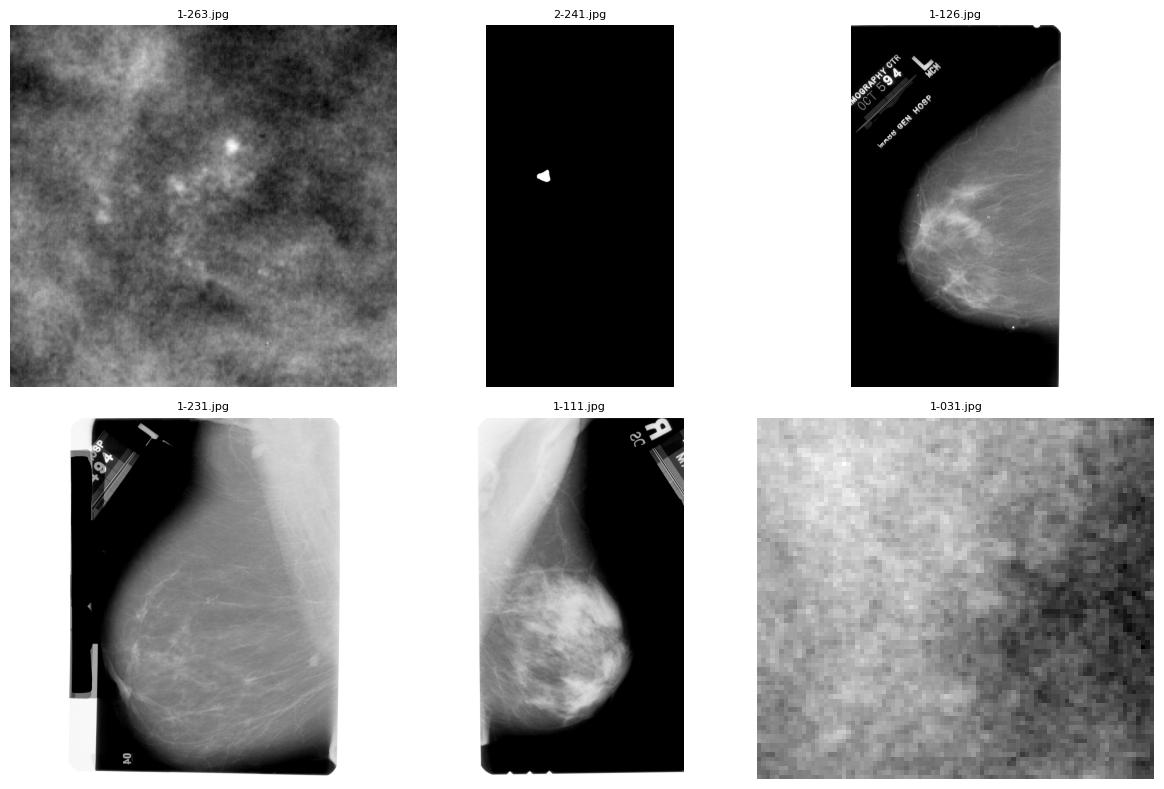

In [6]:
import glob
import matplotlib.pyplot as plt

# Find image files
image_ext = ("*.png", "*.jpg", "*.jpeg")
image_paths = []
for ext in image_ext:
    image_paths.extend(glob.glob(os.path.join(RAW_DATA_PATH, "**", ext), recursive=True))

image_paths = sorted(image_paths)
print(f"Image files found: {len(image_paths)}")

if len(image_paths) == 0:
    dcm_paths = sorted(glob.glob(os.path.join(RAW_DATA_PATH, "**", "*.dcm"), recursive=True))
    print(f"DICOM files found: {len(dcm_paths)}")
    print("No PNG/JPG images available for preview")
else:
    sample_paths = image_paths[:6]
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.ravel()

    # Show sample images
    for i, ax in enumerate(axes):
        ax.axis("off")
        if i < len(sample_paths):
            p = sample_paths[i]
            try:
                img = plt.imread(p)
                ax.imshow(img, cmap="gray")
                ax.set_title(os.path.basename(p), fontsize=8)
            except Exception as e:
                ax.text(0.5, 0.5, f"Read error\n{os.path.basename(p)}", ha="center", va="center", fontsize=8)

    plt.tight_layout()
    plt.show()